# Life Expectancy Prediction
**Dataset:** WHO Life Expectancy Dataset | **Task:** Regression | **Records:** 2,938 | **Features:** 22

**Kaggle:** https://www.kaggle.com/datasets/vikramamin/life-expectancy-who/data

**Live App:** [Life Expectancy Prediction App](https://life-expectancy-app.streamlit.app)

---

#### Import Libraries

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print('All libraries imported successfully.')

All libraries imported successfully.


#### Load Dataset

In [3]:
df = pd.read_csv('Life Expectancy Data.csv')

# Clean column names — remove leading/trailing spaces and double spaces
df.columns = df.columns.str.strip().str.replace(r'\s+', ' ', regex=True)

print(f'Shape: {df.shape}')
print(f'Rows: {df.shape[0]:,}  |  Columns: {df.shape[1]}')
df.head()

Shape: (2938, 22)
Rows: 2,938  |  Columns: 22


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [4]:
print('Data types:')
print(df.dtypes)
print()
df.describe().round(2)

Data types:
Country                             object
Year                                 int64
Status                              object
Life expectancy                    float64
Adult Mortality                    float64
infant deaths                        int64
Alcohol                            float64
percentage expenditure             float64
Hepatitis B                        float64
Measles                              int64
BMI                                float64
under-five deaths                    int64
Polio                              float64
Total expenditure                  float64
Diphtheria                         float64
HIV/AIDS                           float64
GDP                                float64
Population                         float64
thinness 1-19 years                float64
thinness 5-9 years                 float64
Income composition of resources    float64
Schooling                          float64
dtype: object



,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
count,2938.00,2928.00,2928.00,2938.00,2744.00,2938.00,2385.00,2938.00,2904.00,2938.00,2919.00,2712.00,2919.00,2938.00,2490.00,2.286000e+03,2904.00,2904.00,2771.00,2775.00
mean,2007.52,69.22,164.80,30.30,4.60,738.25,80.94,2419.59,38.32,42.04,82.55,5.94,82.32,1.74,7483.16,1.275338e+07,4.84,4.87,0.63,11.99
std,4.61,9.52,124.29,117.93,4.05,1987.91,25.07,11467.27,20.04,160.45,23.43,2.50,23.72,5.08,14270.17,6.101210e+07,4.42,4.51,0.21,3.36
min,2000.00,36.30,1.00,0.00,0.01,0.00,1.00,0.00,1.00,0.00,3.00,0.37,2.00,0.10,1.68,3.400000e+01,0.10,0.10,0.00,0.00
25%,2004.00,63.10,74.00,0.00,0.88,4.69,77.00,0.00,19.30,0.00,78.00,4.26,78.00,0.10,463.94,1.957932e+05,1.60,1.50,0.49,10.10
50%,2008.00,72.10,144.00,3.00,3.76,64.91,92.00,17.00,43.50,4.00,93.00,5.76,93.00,0.10,1766.95,1.386542e+06,3.30,3.30,0.68,12.30
75%,2012.00,75.70,228.00,22.00,7.70,441.53,97.00,360.25,56.20,28.00,97.00,7.49,97.00,0.80,5910.81,7.420359e+06,7.20,7.20,0.78,14.30
max,2015.00,89.00,723.00,1800.00,17.87,19479.91,99.00,212183.00,87.30,2500.00,99.00,17.60,99.00,50.60,119172.74,1.293859e+09,27.70,28.60,0.95,20.70


##  EDA & Visualisations
###  Missing Values

In [5]:
print('Missing values per column:')
print(df.isnull().sum())

Missing values per column:
Country                              0
Year                                 0
Status                               0
Life expectancy                     10
Adult Mortality                     10
infant deaths                        0
Alcohol                            194
percentage expenditure               0
Hepatitis B                        553
Measles                              0
BMI                                 34
under-five deaths                    0
Polio                               19
Total expenditure                  226
Diphtheria                          19
HIV/AIDS                             0
GDP                                448
Population                         652
thinness 1-19 years                 34
thinness 5-9 years                  34
Income composition of resources    167
Schooling                          163
dtype: int64


### Target Variable Distribution

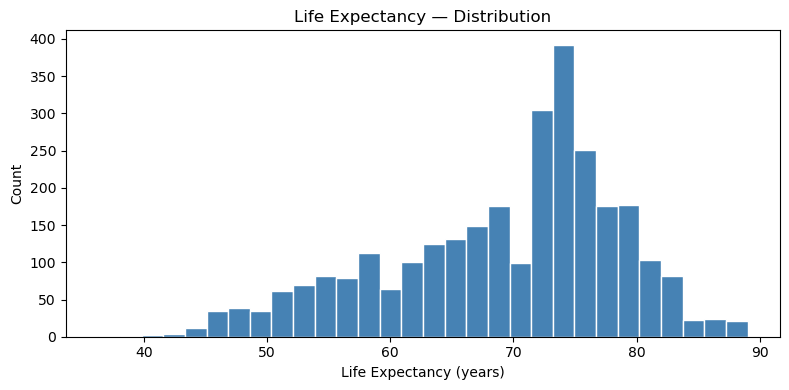

Mean   : 69.22 years
Median : 72.10 years
Std    : 9.52 years
Min    : 36.3 years
Max    : 89.0 years


In [6]:
# Histogram
plt.figure(figsize=(8, 4))
plt.hist(df['Life expectancy'].dropna(), bins=30, color='steelblue', edgecolor='white')
plt.title('Life Expectancy — Distribution')
plt.xlabel('Life Expectancy (years)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

print(f"Mean   : {df['Life expectancy'].mean():.2f} years")
print(f"Median : {df['Life expectancy'].median():.2f} years")
print(f"Std    : {df['Life expectancy'].std():.2f} years")
print(f"Min    : {df['Life expectancy'].min():.1f} years")
print(f"Max    : {df['Life expectancy'].max():.1f} years")

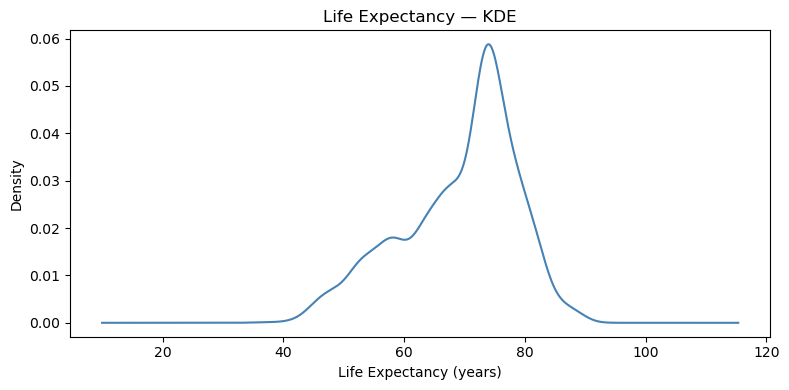

In [7]:
# KDE plot
plt.figure(figsize=(8, 4))
df['Life expectancy'].dropna().plot(kind='kde', color='steelblue')
plt.title('Life Expectancy — KDE')
plt.xlabel('Life Expectancy (years)')
plt.tight_layout()
plt.show()

<Figure size 700x500 with 0 Axes>

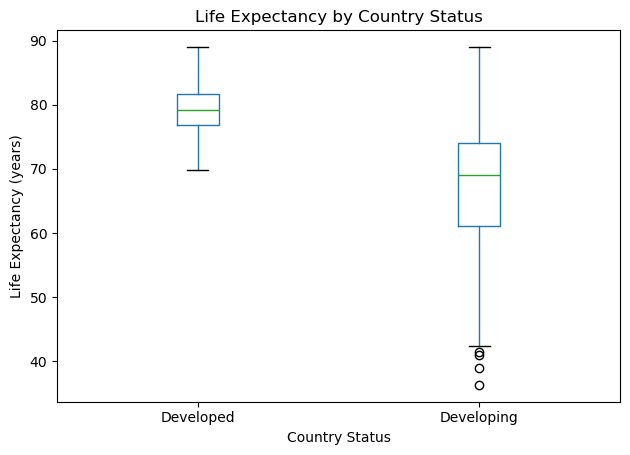

In [8]:
# Boxplot by Status
plt.figure(figsize=(7, 5))
df.boxplot(column='Life expectancy', by='Status', grid=False)
plt.title('Life Expectancy by Country Status')
plt.suptitle('')
plt.xlabel('Country Status')
plt.ylabel('Life Expectancy (years)')
plt.tight_layout()
plt.show()

### Life Expectancy Over Time

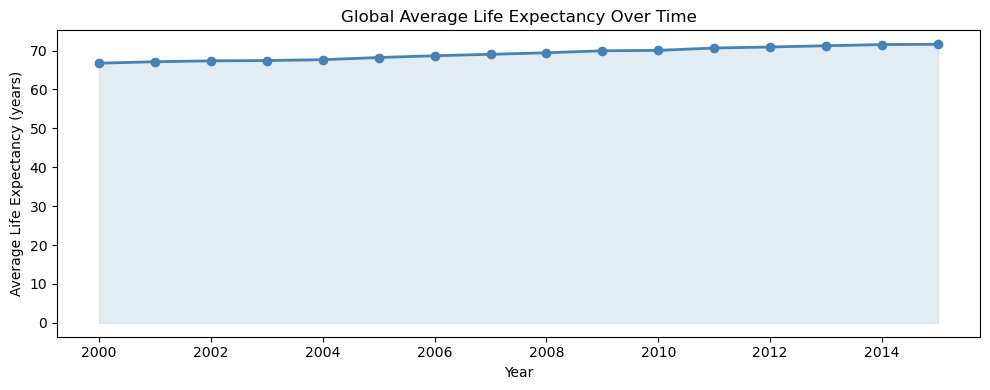

In [9]:
yearly = df.groupby('Year')['Life expectancy'].mean()
plt.figure(figsize=(10, 4))
plt.plot(yearly.index, yearly.values, marker='o', linewidth=2, color='steelblue')
plt.fill_between(yearly.index, yearly.values, alpha=0.15, color='steelblue')
plt.title('Global Average Life Expectancy Over Time')
plt.xlabel('Year')
plt.ylabel('Average Life Expectancy (years)')
plt.tight_layout()
plt.show()

### Correlation Heatmap

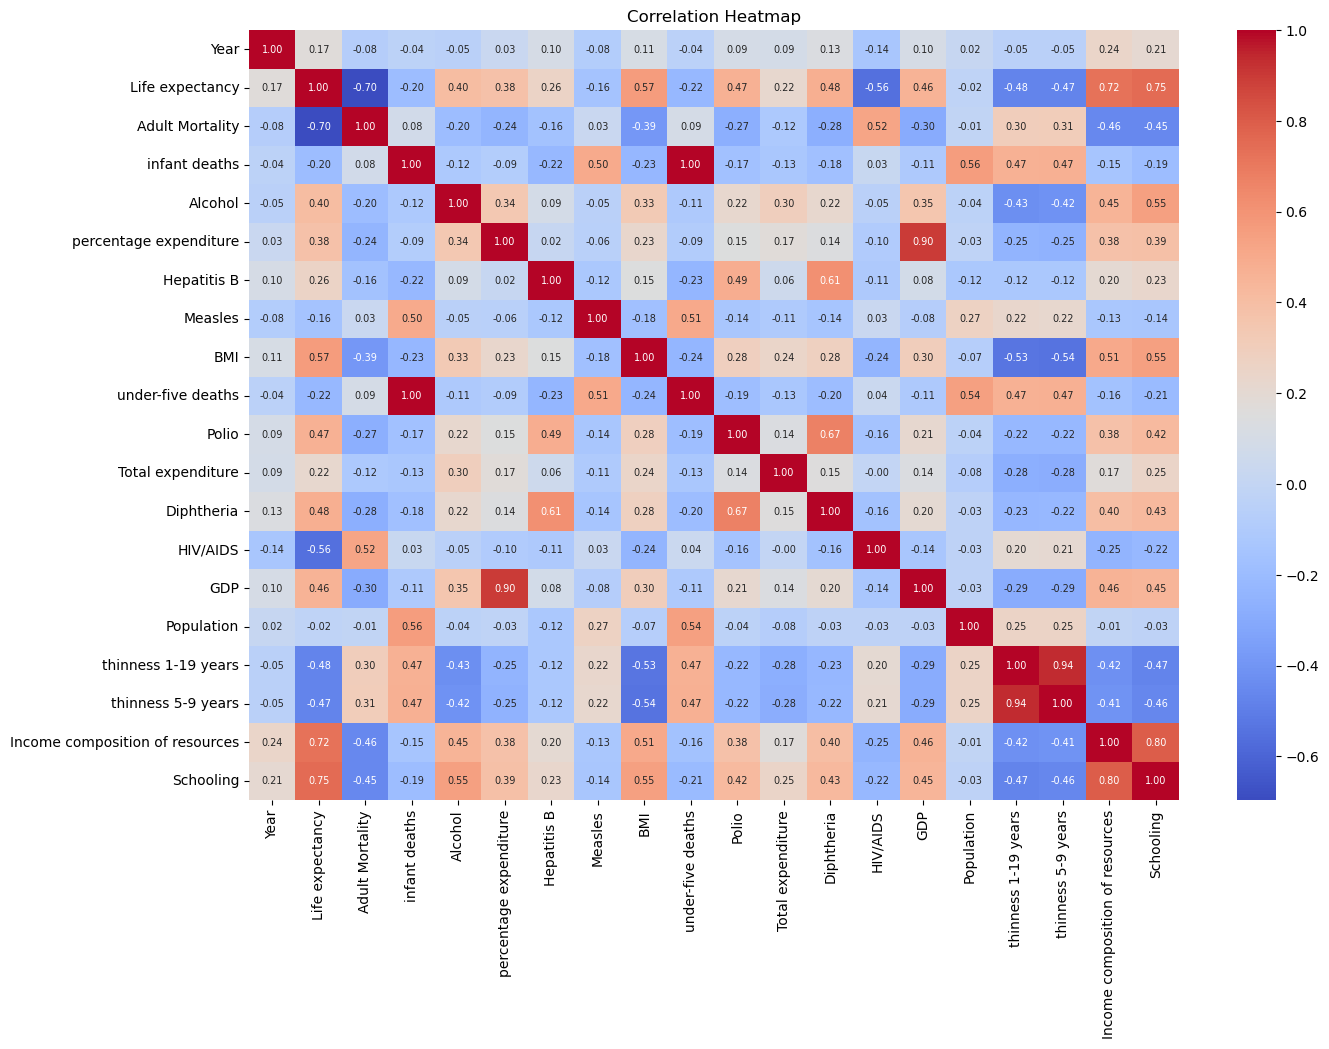

Correlations with Life Expectancy:
Life expectancy                    1.000
Schooling                          0.752
Income composition of resources    0.725
BMI                                0.568
Diphtheria                         0.479
Polio                              0.466
GDP                                0.461
Alcohol                            0.405
percentage expenditure             0.382
Hepatitis B                        0.257
Total expenditure                  0.218
Year                               0.170
Population                        -0.022
Measles                           -0.158
infant deaths                     -0.197
under-five deaths                 -0.223
thinness 5-9 years                -0.472
thinness 1-19 years               -0.477
HIV/AIDS                          -0.557
Adult Mortality                   -0.696
Name: Life expectancy, dtype: float64


In [10]:
plt.figure(figsize=(15, 10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm',
            annot=True, fmt='.2f', annot_kws={'size': 7})
plt.title('Correlation Heatmap')
plt.show()

# Ranked correlations with target
corr = df.corr(numeric_only=True)
print('Correlations with Life Expectancy:')
print(corr['Life expectancy'].sort_values(ascending=False).round(3))

### Handle Missing Values

In [11]:
# Drop rows where target is missing
df.dropna(subset=['Life expectancy'], inplace=True)

# Impute numeric columns with median
numeric_cols = df.select_dtypes(include=np.number).columns
for col in numeric_cols:
    df[col] = df[col].fillna(df[col].median())

print(f'Missing values remaining: {df.isnull().sum().sum()}')
print(f'Final shape: {df.shape}')

Missing values remaining: 0
Final shape: (2928, 22)


### Skewness Check & Transformations

In [12]:
numeric_cols = df.select_dtypes(include=np.number).columns
skewness = df[numeric_cols].skew().sort_values(ascending=False)
print('Skewness of all numeric features:')
print(skewness.round(3))

high_skew = skewness[skewness.abs() > 1.0].index.tolist()
print(f'\nHighly skewed (|skew| > 1.0): {high_skew}')

Skewness of all numeric features:
Population                         17.943
infant deaths                       9.771
under-five deaths                   9.480
Measles                             9.425
HIV/AIDS                            5.387
percentage expenditure              4.644
GDP                                 3.537
thinness 5-9 years                  1.794
thinness 1-19 years                 1.728
Adult Mortality                     1.174
Alcohol                             0.647
Total expenditure                   0.618
Year                                0.000
BMI                                -0.240
Schooling                          -0.615
Life expectancy                    -0.639
Income composition of resources    -1.208
Diphtheria                         -2.083
Polio                              -2.109
Hepatitis B                        -2.286
dtype: float64

Highly skewed (|skew| > 1.0): ['Population', 'infant deaths', 'under-five deaths', 'Measles', 'HIV/AIDS', 'per

In [13]:
# Apply log1p to positive skewed features
positive_skew = ['Population', 'infant deaths', 'under-five deaths',
                 'Measles', 'HIV/AIDS', 'percentage expenditure',
                 'GDP', 'thinness 5-9 years', 'thinness 1-19 years',
                 'Adult Mortality']
for col in positive_skew:
    df[col] = np.log1p(df[col])

# HIV/AIDS still skewed — apply sqrt
df['HIV/AIDS'] = np.sqrt(df['HIV/AIDS'])

print('Skewness after transformation:')
print(df[positive_skew].skew().round(3))

Skewness after transformation:
Population               -0.692
infant deaths             0.698
under-five deaths         0.643
Measles                   0.551
HIV/AIDS                  1.463
percentage expenditure   -0.080
GDP                      -0.155
thinness 5-9 years        0.116
thinness 1-19 years       0.145
Adult Mortality          -1.126
dtype: float64


### Outlier Detection

In [14]:
# IQR method
numeric_cols = df.select_dtypes(include=np.number).columns
print('Outlier counts per feature (IQR method):')
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    n_out = ((df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)).sum()
    print(f'  {col:<35} : {n_out}')

Outlier counts per feature (IQR method):
  Year                                : 0
  Life expectancy                     : 10
  Adult Mortality                     : 166
  infant deaths                       : 0
  Alcohol                             : 3
  percentage expenditure              : 0
  Hepatitis B                         : 320
  Measles                             : 0
  BMI                                 : 0
  under-five deaths                   : 0
  Polio                               : 278
  Total expenditure                   : 49
  Diphtheria                          : 297
  HIV/AIDS                            : 176
  GDP                                 : 32
  Population                          : 144
  thinness 1-19 years                 : 0
  thinness 5-9 years                  : 0
  Income composition of resources     : 130
  Schooling                           : 75


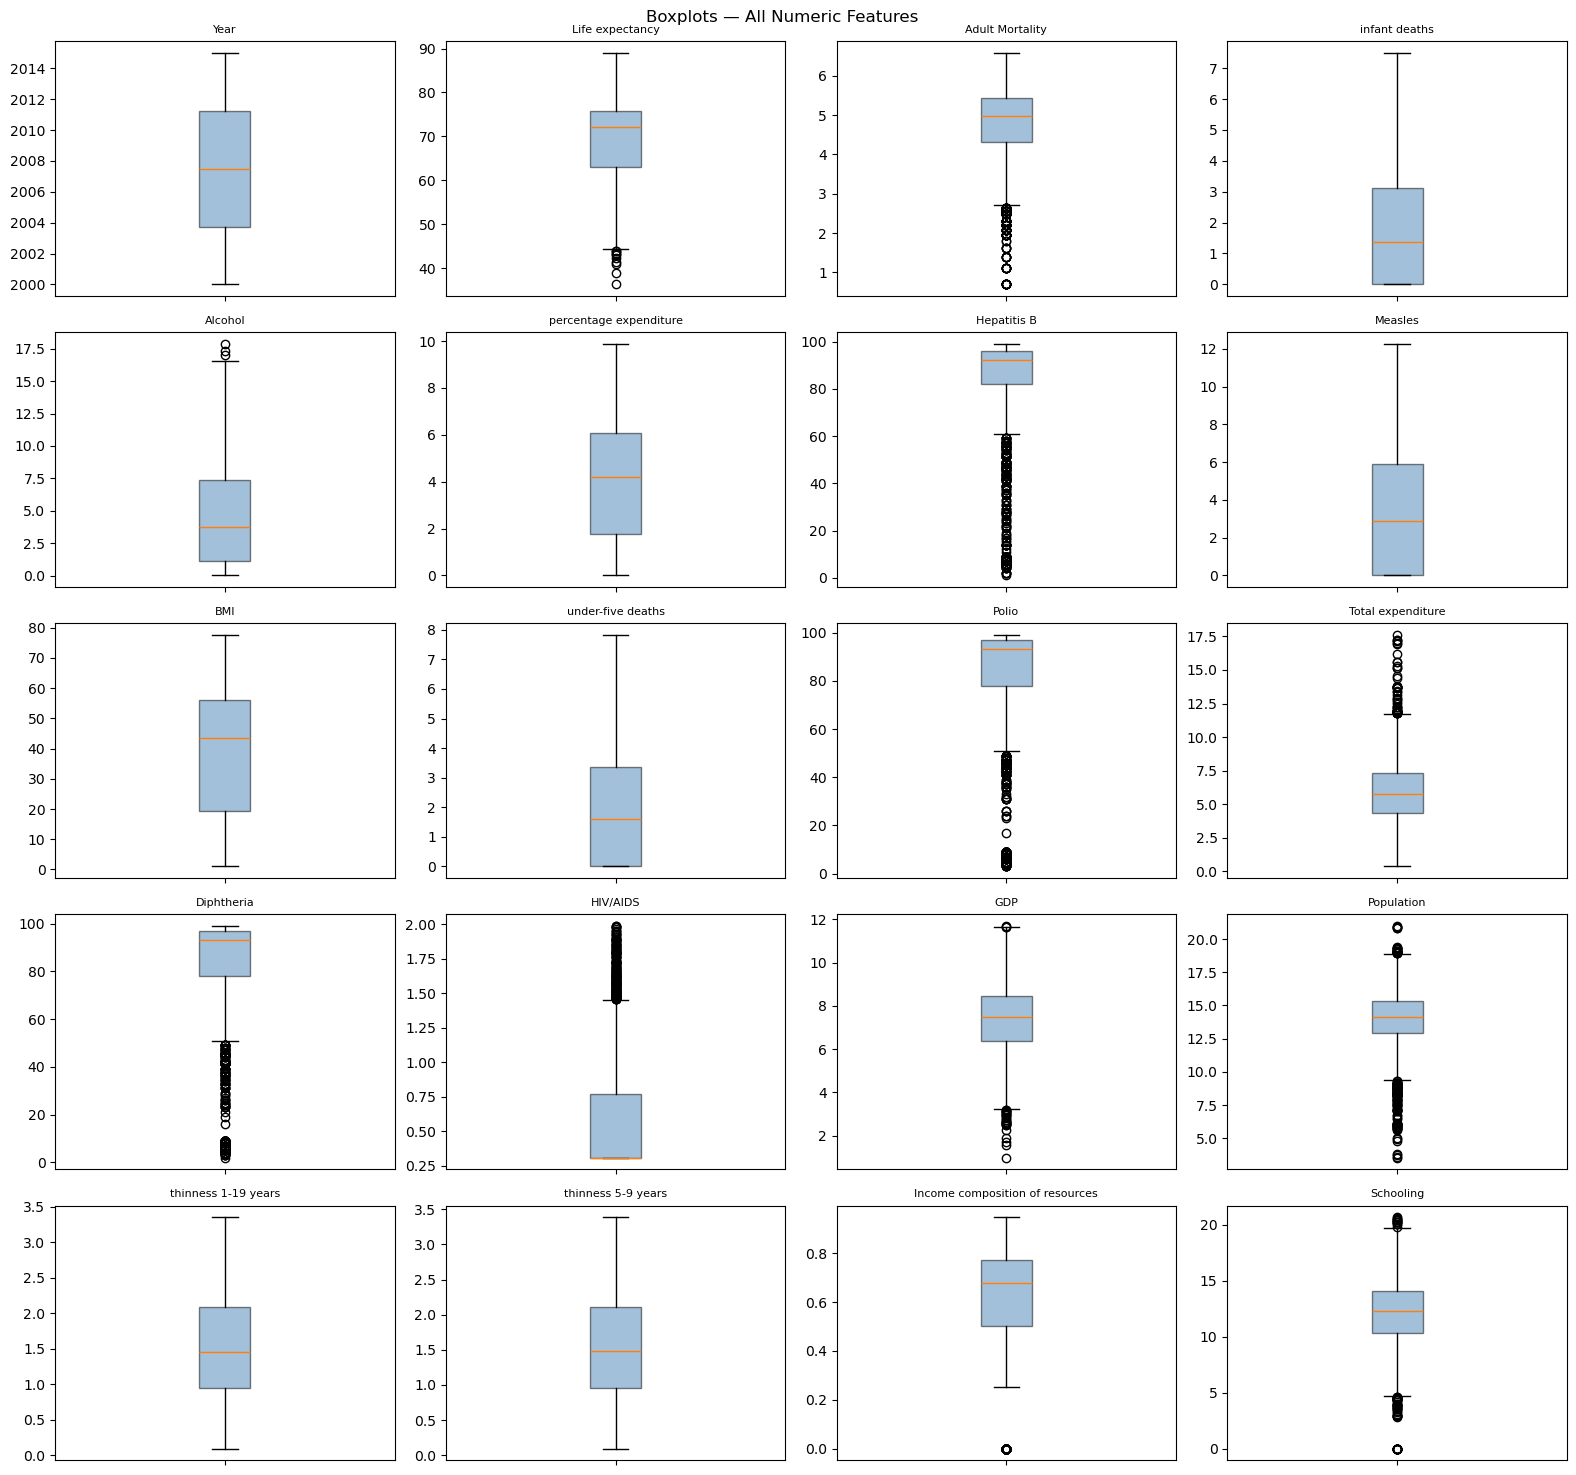

Outliers are real data points (vaccination rates, mortality) — Winsorization skipped.
Tree-based models are robust to outliers.


In [15]:
# Boxplots for all numeric features
n_cols = 4
n_rows = int(np.ceil(len(numeric_cols) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
axes = axes.flatten()
for i, col in enumerate(numeric_cols):
    axes[i].boxplot(df[col], patch_artist=True,
                    boxprops=dict(facecolor='steelblue', alpha=0.5))
    axes[i].set_title(col, fontsize=8)
    axes[i].tick_params(labelbottom=False)
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Boxplots — All Numeric Features', fontsize=12)
plt.tight_layout()
plt.show()

print('Outliers are real data points (vaccination rates, mortality) — Winsorization skipped.')
print('Tree-based models are robust to outliers.')

### Preprocessing & Feature Scaling

In [16]:
# Encode Status
le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'].astype(str))
print('Status encoded — Developed=1, Developing=0')
print(df['Status'].value_counts())

Status encoded — Developed=1, Developing=0
Status
1    2416
0     512
Name: count, dtype: int64


In [17]:
# Define features and target
X = df.drop(columns=['Country', 'Life expectancy'])
y = df['Life expectancy']

# Train-Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)

# StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train.shape[0]} rows | Test: {X_test.shape[0]} rows')
print(f'Features: {X.shape[1]}')
print('StandardScaler applied — fitted on train only (no data leakage)')

Train: 2342 rows | Test: 586 rows
Features: 20
StandardScaler applied — fitted on train only (no data leakage)


### Model Training - All Supervised ML Algorithms

In [18]:
# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_pred = lr.predict(X_test_scaled)
print('Linear Regression:')
print(f'  R²  : {r2_score(y_test, lr_pred):.4f}')
print(f'  MAE : {mean_absolute_error(y_test, lr_pred):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, lr_pred)):.4f}')

Linear Regression:
  R²  : 0.8424
  MAE : 2.8374
  RMSE: 3.6920


In [19]:
# Decision Tree
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
dt_pred = dt.predict(X_test_scaled)
print('Decision Tree:')
print(f'  R²  : {r2_score(y_test, dt_pred):.4f}')
print(f'  MAE : {mean_absolute_error(y_test, dt_pred):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, dt_pred)):.4f}')

Decision Tree:
  R²  : 0.9178
  MAE : 1.6171
  RMSE: 2.6673


In [20]:
# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
rf_pred = rf.predict(X_test_scaled)
print('Random Forest:')
print(f'  R²  : {r2_score(y_test, rf_pred):.4f}')
print(f'  MAE : {mean_absolute_error(y_test, rf_pred):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, rf_pred)):.4f}')

Random Forest:
  R²  : 0.9674
  MAE : 1.0537
  RMSE: 1.6800


In [21]:
# SVR
svr = SVR(kernel='rbf', C=10, epsilon=0.1)
svr.fit(X_train_scaled, y_train)
svr_pred = svr.predict(X_test_scaled)
print('SVR:')
print(f'  R²  : {r2_score(y_test, svr_pred):.4f}')
print(f'  MAE : {mean_absolute_error(y_test, svr_pred):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, svr_pred)):.4f}')

SVR:
  R²  : 0.9379
  MAE : 1.5388
  RMSE: 2.3168


In [22]:
# XGBoost
xgb = XGBRegressor(n_estimators=200, learning_rate=0.05,
                   max_depth=4, random_state=42, verbosity=0)
xgb.fit(X_train_scaled, y_train)
xgb_pred = xgb.predict(X_test_scaled)
print('XGBoost:')
print(f'  R²  : {r2_score(y_test, xgb_pred):.4f}')
print(f'  MAE : {mean_absolute_error(y_test, xgb_pred):.4f}')
print(f'  RMSE: {np.sqrt(mean_squared_error(y_test, xgb_pred)):.4f}')

XGBoost:
  R²  : 0.9564
  MAE : 1.3358
  RMSE: 1.9412


### Overfitting Check & Treatment

In [23]:
models_dict = {
    'Linear Regression': (lr, lr_pred),
    'Decision Tree'    : (dt, dt_pred),
    'Random Forest'    : (rf, rf_pred),
    'SVR'              : (svr, svr_pred),
    'XGBoost'          : (xgb, xgb_pred)
}

print(f"{'Model':<22} {'Train R²':>10} {'Test R²':>10} {'Gap':>10}")
print('-' * 55)
for name, (model, test_pred) in models_dict.items():
    train_r2 = r2_score(y_train, model.predict(X_train_scaled))
    test_r2  = r2_score(y_test, test_pred)
    gap      = train_r2 - test_r2
    print(f'{name:<22} {train_r2:>10.4f} {test_r2:>10.4f} {gap:>10.4f}')

Model                    Train R²    Test R²        Gap
-------------------------------------------------------
Linear Regression          0.8514     0.8424     0.0090
Decision Tree              1.0000     0.9178     0.0822
Random Forest              0.9947     0.9674     0.0273
SVR                        0.9599     0.9379     0.0219
XGBoost                    0.9742     0.9564     0.0178


Best max_depth: 9
Best Test R²  : 0.9354


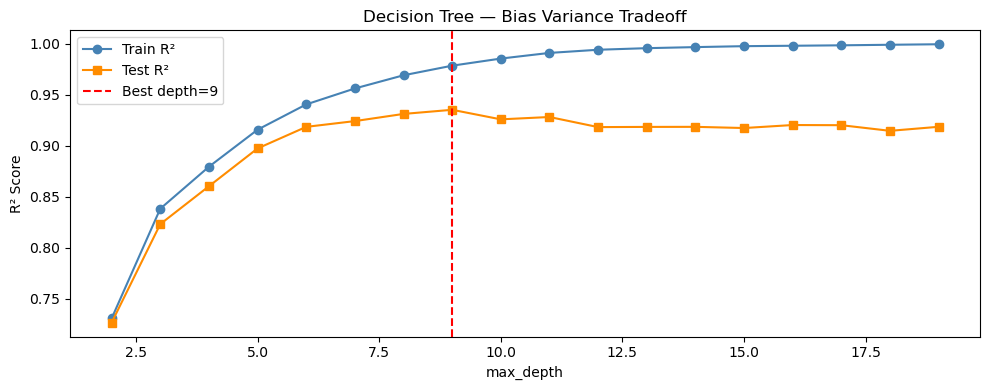

In [24]:
# Decision Tree overfitting treatment — find best max_depth
train_r2_list, test_r2_list = [], []
depths = range(2, 20)

for d in depths:
    dt_temp = DecisionTreeRegressor(max_depth=d, random_state=42)
    dt_temp.fit(X_train_scaled, y_train)
    train_r2_list.append(r2_score(y_train, dt_temp.predict(X_train_scaled)))
    test_r2_list.append(r2_score(y_test,   dt_temp.predict(X_test_scaled)))

best_depth = depths[np.argmax(test_r2_list)]
print(f'Best max_depth: {best_depth}')
print(f'Best Test R²  : {max(test_r2_list):.4f}')

plt.figure(figsize=(10, 4))
plt.plot(depths, train_r2_list, marker='o', label='Train R²', color='steelblue')
plt.plot(depths, test_r2_list,  marker='s', label='Test R²',  color='darkorange')
plt.axvline(best_depth, color='red', linestyle='--', linewidth=1.5,
            label=f'Best depth={best_depth}')
plt.xlabel('max_depth')
plt.ylabel('R² Score')
plt.title('Decision Tree — Bias Variance Tradeoff')
plt.legend()
plt.tight_layout()
plt.show()

In [26]:
# Retrain Decision Tree with best depth
dt_tuned = DecisionTreeRegressor(max_depth=best_depth, random_state=42)
dt_tuned.fit(X_train_scaled, y_train)
dt_tuned_pred = dt_tuned.predict(X_test_scaled)

train_r2 = r2_score(y_train, dt_tuned.predict(X_train_scaled))
test_r2  = r2_score(y_test, dt_tuned_pred)
print(f'Tuned DT - Train R²: {train_r2:.4f} | Test R²: {test_r2:.4f} | Gap: {train_r2-test_r2:.4f}')

Tuned DT - Train R²: 0.9787 | Test R²: 0.9354 | Gap: 0.0433


### Final Model Comparison

In [27]:
final_models = {
    'Linear Regression'   : (lr, lr_pred),
    'Decision Tree (Tuned)': (dt_tuned, dt_tuned_pred),
    'Random Forest'        : (rf, rf_pred),
    'SVR'                  : (svr, svr_pred),
    'XGBoost'              : (xgb, xgb_pred)
}

results = []
print(f"{'Model':<25} {'Train R²':>10} {'Test R²':>10} {'MAE':>8} {'RMSE':>8} {'Gap':>8}")
print('-' * 75)
for name, (model, test_pred) in final_models.items():
    train_r2 = r2_score(y_train, model.predict(X_train_scaled))
    test_r2  = r2_score(y_test, test_pred)
    mae      = mean_absolute_error(y_test, test_pred)
    rmse     = np.sqrt(mean_squared_error(y_test, test_pred))
    gap      = train_r2 - test_r2
    results.append({'Model': name, 'Train R²': round(train_r2,4),
                    'Test R²': round(test_r2,4), 'MAE': round(mae,4),
                    'RMSE': round(rmse,4), 'Gap': round(gap,4)})
    print(f'{name:<25} {train_r2:>10.4f} {test_r2:>10.4f} {mae:>8.4f} {rmse:>8.4f} {gap:>8.4f}')

results_df = pd.DataFrame(results).sort_values('Test R²', ascending=False)
print(f"\nBest Model: {results_df.iloc[0]['Model']} | Test R²: {results_df.iloc[0]['Test R²']}")

Model                       Train R²    Test R²      MAE     RMSE      Gap
---------------------------------------------------------------------------
Linear Regression             0.8514     0.8424   2.8374   3.6920   0.0090
Decision Tree (Tuned)         0.9787     0.9354   1.5458   2.3642   0.0433
Random Forest                 0.9947     0.9674   1.0537   1.6800   0.0273
SVR                           0.9599     0.9379   1.5388   2.3168   0.0219
XGBoost                       0.9742     0.9564   1.3358   1.9412   0.0178

Best Model: Random Forest | Test R²: 0.9674


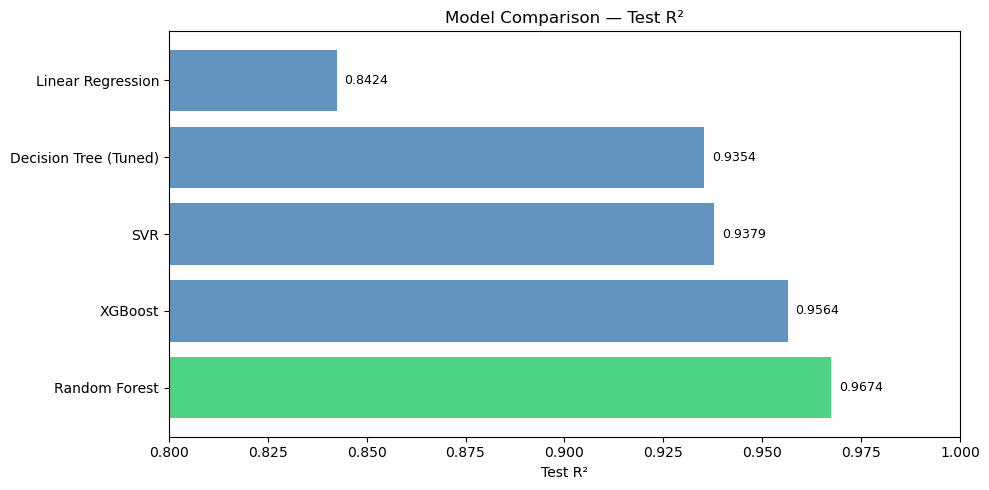

In [28]:
# Bar chart — Test R² comparison
plt.figure(figsize=(10, 5))
colors = ['#2ecc71' if i == 0 else 'steelblue' for i in range(len(results_df))]
bars = plt.barh(results_df['Model'], results_df['Test R²'], color=colors, alpha=0.85)
plt.xlabel('Test R²')
plt.title('Model Comparison — Test R²')
plt.xlim(0.8, 1.0)
for bar, val in zip(bars, results_df['Test R²']):
    plt.text(bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()

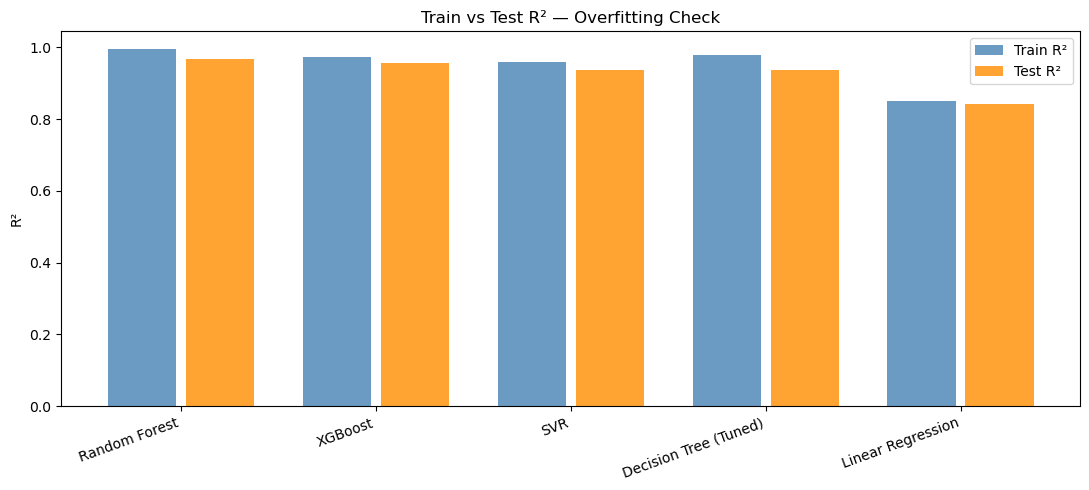

In [29]:
# Train vs Test R² — overfitting check
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(results_df))
ax.bar(x - 0.2, results_df['Train R²'], 0.35, label='Train R²', color='steelblue', alpha=0.8)
ax.bar(x + 0.2, results_df['Test R²'],  0.35, label='Test R²',  color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right')
ax.set_ylabel('R²')
ax.set_title('Train vs Test R² — Overfitting Check')
ax.legend()
plt.tight_layout()
plt.show()

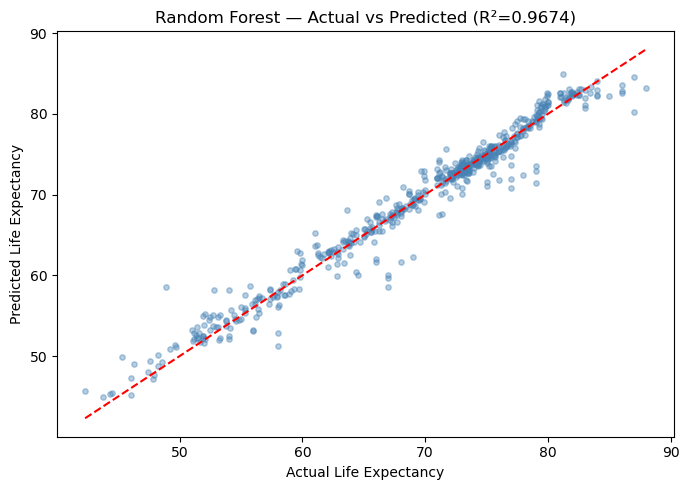

In [30]:
# Actual vs Predicted — Best Model (Random Forest)
plt.figure(figsize=(7, 5))
plt.scatter(y_test, rf_pred, alpha=0.4, color='steelblue', s=15)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', linewidth=1.5)
plt.xlabel('Actual Life Expectancy')
plt.ylabel('Predicted Life Expectancy')
plt.title(f'Random Forest — Actual vs Predicted (R²={r2_score(y_test, rf_pred):.4f})')
plt.tight_layout()
plt.show()

### Feature Importance - Best Model

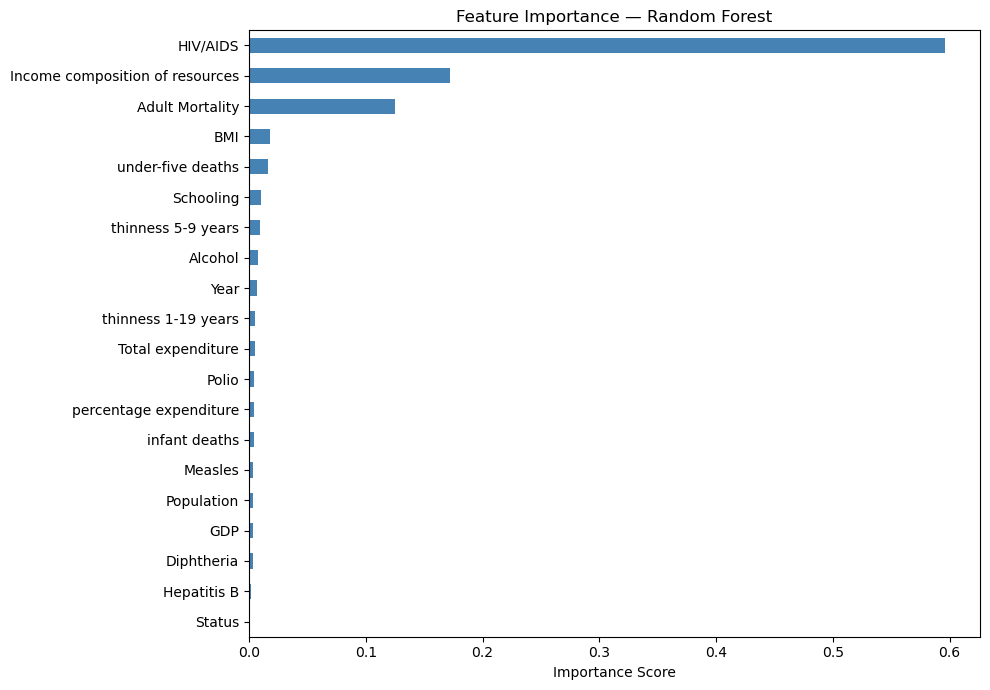

Top 5 most important features:
HIV/AIDS                           0.5961
Income composition of resources    0.1720
Adult Mortality                    0.1248
BMI                                0.0177
under-five deaths                  0.0163
dtype: float64


In [31]:
feat_imp = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=True)

plt.figure(figsize=(10, 7))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='none')
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print('Top 5 most important features:')
print(feat_imp.sort_values(ascending=False).head(5).round(4))

### Summary

| Model | Test R² | MAE | RMSE | Gap |
|---|---|---|---|---|
| **Random Forest** | **0.9674** | **1.0537** | **1.6800** | 0.0273 |
| XGBoost | 0.9564 | 1.3358 | 1.9412 | 0.0178 |
| SVR | 0.9379 | 1.5388 | 2.3168 | 0.0219 |
| Decision Tree (Tuned) | 0.9354 | 1.5458 | 2.3642 | 0.0433 |
| Linear Regression | 0.8424 | 2.8374 | 3.6920 | 0.0090 |

**Best Model: Random Forest**
- Highest Test R² (0.9674) — explains 96.7% of variance
- Lowest MAE (1.05 years) — predictions within ~1 year
- Top predictors: HIV/AIDS, Income composition, Adult Mortality

---
**Live App:** [Life Expectancy Prediction App](https://life-expectancy-app.streamlit.app)